In [1]:
%reload_ext autoreload
%autoreload 2

from utils.custom_sounds import Tone, Click, Click_Train
import brian2 as b2
import brian2hears as b2h
import matplotlib.pyplot as plt
import numpy as np
from analyze.report import plot_sound, plot_anf_rasterplot

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Sound waveform'}, xlabel='Time (s)', ylabel='Amplitude'>)

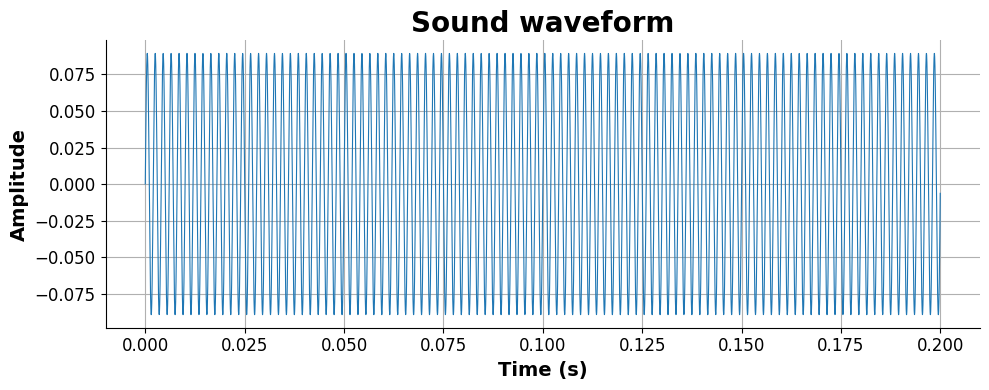

In [2]:
t = Tone(0.5 * b2.kHz, 200 * b2.ms, level=70 * b2h.dB)
plot_sound(t.sound)

22.67573696 us
Sound duration 199.97732426 ms, channels 1, samplerate 44.1 kHz


(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Sound waveform'}, xlabel='Time (s)', ylabel='Amplitude'>)

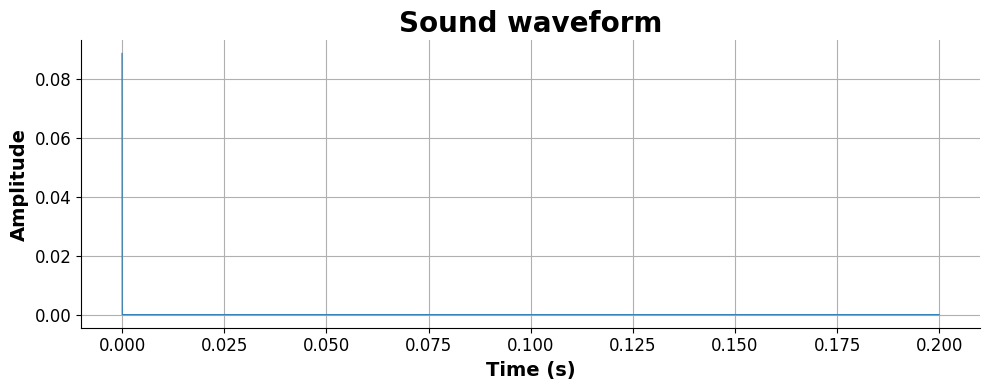

In [3]:
c = Click(duration= 200*b2.ms, click_duration=1, level=70 * b2h.dB)
plot_sound(c.sound)

(array([[8.72708227e-11, 2.82975993e-10, 5.16913731e-10, ...,
         6.14627414e-10, 7.54619965e-10, 7.61288585e-10],
        [5.84280044e-09, 6.49967004e-09, 7.28486435e-09, ...,
         7.61283293e-09, 8.08270734e-09, 8.10509005e-09],
        [5.12987456e-06, 5.12071678e-06, 5.10976996e-06, ...,
         5.10519757e-06, 5.09864679e-06, 5.09833474e-06],
        ...,
        [2.30416080e-20, 1.97683826e-20, 1.58557065e-20, ...,
         1.42214196e-20, 1.18800028e-20, 1.17684678e-20],
        [2.21988460e-20, 1.67100511e-20, 1.01489764e-20, ...,
         1.00000000e-20, 1.00000000e-20, 1.00000000e-20],
        [1.09591456e-20, 1.00000000e-20, 1.00000000e-20, ...,
         1.00000000e-20, 1.00000000e-20, 1.00000000e-20]]),
 array([ 0.        ,  0.17226563,  0.34453125,  0.51679688,  0.6890625 ,
         0.86132812,  1.03359375,  1.20585937,  1.378125  ,  1.55039062,
         1.72265625,  1.89492188,  2.0671875 ,  2.23945312,  2.41171875,
         2.58398438,  2.75625   ,  2.92851563,

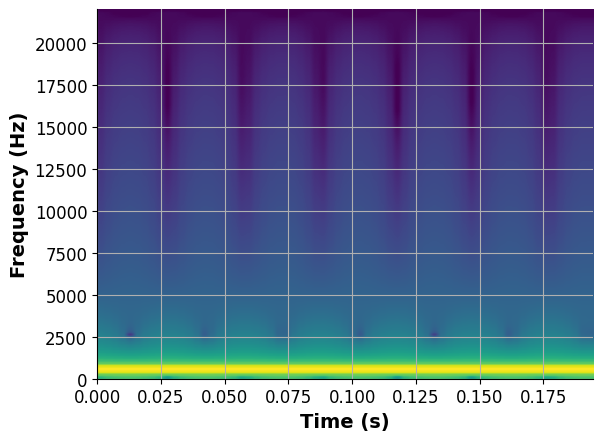

In [4]:
t.sound.spectrogram()

WARNING    /Users/francescodesantis/miniforge3/envs/sl_env/lib/python3.9/site-packages/matplotlib/axes/_axes.py:8089: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)
 [py.warnings]


(array([[1.e-20, 1.e-20, 1.e-20, ..., 1.e-20, 1.e-20, 1.e-20],
        [1.e-20, 1.e-20, 1.e-20, ..., 1.e-20, 1.e-20, 1.e-20],
        [1.e-20, 1.e-20, 1.e-20, ..., 1.e-20, 1.e-20, 1.e-20],
        ...,
        [1.e-20, 1.e-20, 1.e-20, ..., 1.e-20, 1.e-20, 1.e-20],
        [1.e-20, 1.e-20, 1.e-20, ..., 1.e-20, 1.e-20, 1.e-20],
        [1.e-20, 1.e-20, 1.e-20, ..., 1.e-20, 1.e-20, 1.e-20]]),
 array([ 0.        ,  0.17226563,  0.34453125,  0.51679688,  0.6890625 ,
         0.86132812,  1.03359375,  1.20585937,  1.378125  ,  1.55039062,
         1.72265625,  1.89492188,  2.0671875 ,  2.23945312,  2.41171875,
         2.58398438,  2.75625   ,  2.92851563,  3.10078125,  3.27304687,
         3.4453125 ,  3.61757813,  3.78984375,  3.96210937,  4.134375  ,
         4.30664062,  4.47890625,  4.65117188,  4.8234375 ,  4.99570313,
         5.16796875,  5.34023437,  5.5125    ,  5.68476562,  5.85703125,
         6.02929688,  6.2015625 ,  6.37382813,  6.54609375,  6.71835938,
         6.890625  ,  7

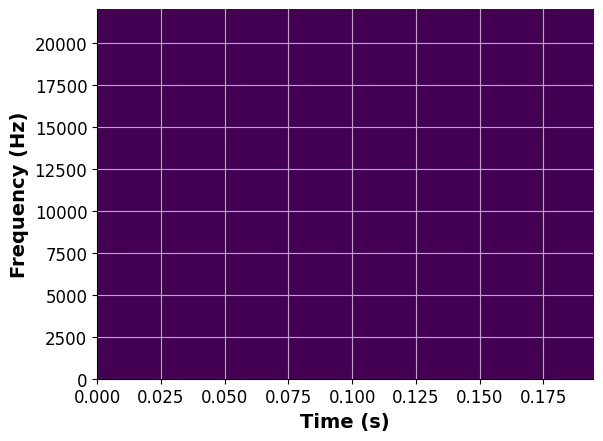

In [5]:
c.sound.spectrogram()

In [7]:
import sys
from pathlib import Path

# Detect root of the repo
REPO_ROOT = Path(__file__).resolve().parents[1] if "__file__" in globals() else Path().resolve().parents[0]

# Add simulate/ and repo root to sys.path
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "simulate"))

print("Repo root:", REPO_ROOT)

Repo root: /Users/francescodesantis/Documents/repos/sound_localization_model


In [8]:
from simulate.models.BrainstemModel.params import Parameters as params
from simulate.utils.anf_utils import load_anf_response, ZI_COC_KEY
from simulate.utils.hrtf_utils import apply_gating

✅ Using local cochlea package from: /Users/francescodesantis/Documents/repos/cochlea-1
/Users/francescodesantis/Documents/repos/sound_localization_model/simulate
✅ Using utils from: /Users/francescodesantis/Documents/repos/sound_localization_model/simulate

              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.8.0
 Built: Jul 24 2025 05:26:03

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



In [9]:
gated_sound = apply_gating(t.sound, ramp_ms=10.0)

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Sound waveform'}, xlabel='Time (s)', ylabel='Amplitude'>)

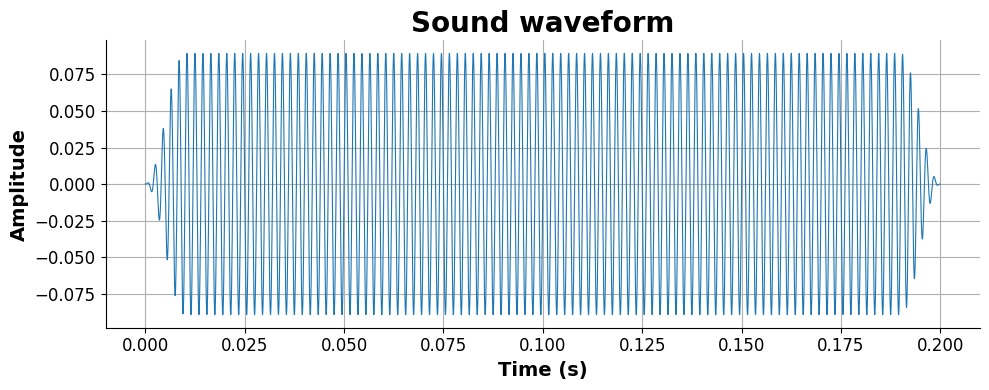

In [10]:
plot_sound(gated_sound)

In [11]:
p = params("gating_test")

In [12]:
anf = load_anf_response(t, cochlea_key=ZI_COC_KEY, params=p.cochlea, angle = 90)

2025-11-17 15:51:26,366 [INFO ]  generating ANF for {'sound': <utils.custom_sounds.Tone object at 0x10622b940>, 'angle': 90, 'cochlea_key': 'Zilany', 'params': {'hrtf_params': {'subj_number': 1, 'itd_remove_strategy': 'estimate_from_hrtf'}, 'cochlea_params': {'anf_num': (10, 0, 0), 'species': 'human', 'cohc': 1.0, 'cihc': 1.0, 'powerlaw': 'approximate', 'ffGn': False}, 'rng_seed': 42, 'omni_noise_level': 0}}


In [13]:
g_anf = load_anf_response(gated_sound, cochlea_key=ZI_COC_KEY, params=p.cochlea, angle = 90)

2025-11-17 15:51:34,511 [INFO ]  generating ANF for {'sound': Sound(
    array([[ 0.00000000e+00],
           [ 8.07699146e-08],
           [ 6.44512255e-07],
           ...,
           [-9.62679535e-07],
           [-1.61130108e-07],
           [-0.00000000e+00]]),
    44.1 * khertz), 'angle': 90, 'cochlea_key': 'Zilany', 'params': {'hrtf_params': {'subj_number': 1, 'itd_remove_strategy': 'estimate_from_hrtf'}, 'cochlea_params': {'anf_num': (10, 0, 0), 'species': 'human', 'cohc': 1.0, 'cihc': 1.0, 'powerlaw': 'approximate', 'ffGn': False}, 'rng_seed': 42, 'omni_noise_level': 0}}


(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Sound waveform'}, xlabel='Time (s)', ylabel='Amplitude'>)

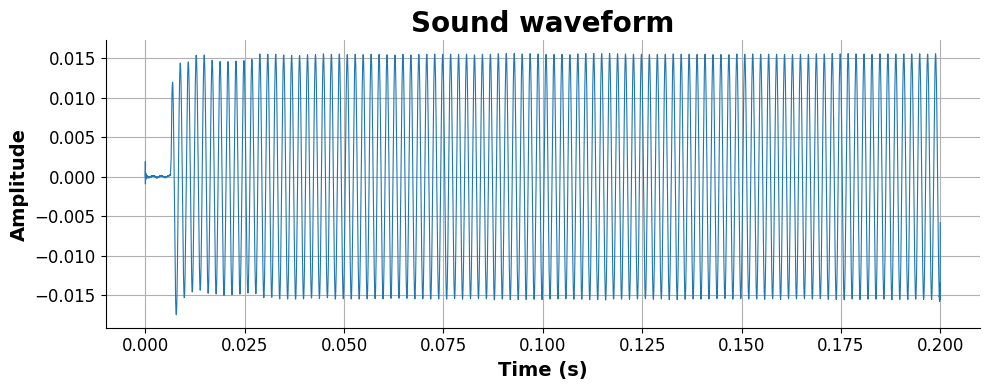

In [14]:
plot_sound(anf.left)

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Sound waveform'}, xlabel='Time (s)', ylabel='Amplitude'>)

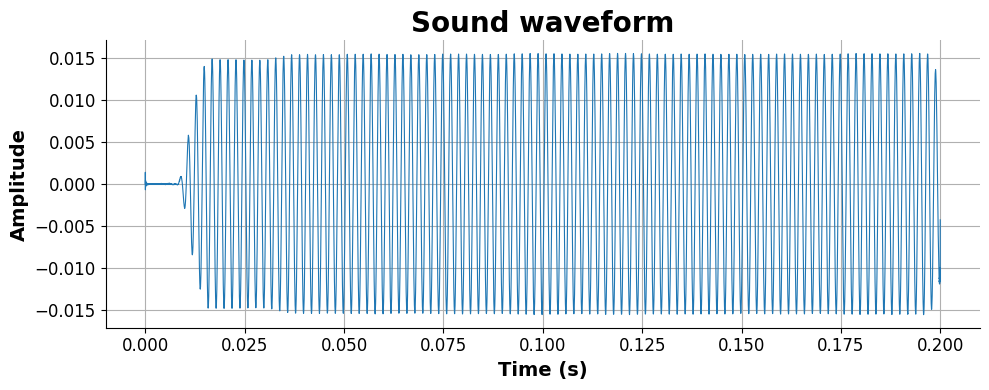

In [15]:
plot_sound(g_anf.left)

In [18]:
anf.left.level

54.59197759849231*dB

In [20]:
g_anf.left.level

54.432215745774506*dB

(array([[1.47183261e-13, 4.39239838e-13, 1.76880561e-12, ...,
         3.75860338e-08, 1.33235039e-08, 2.21366470e-09],
        [5.19620223e-12, 9.18011971e-12, 1.02778663e-11, ...,
         1.75515916e-07, 1.88334573e-07, 1.94076661e-07],
        [2.29733160e-12, 4.65866592e-12, 5.16372864e-12, ...,
         1.05271849e-07, 1.02419024e-07, 1.01187337e-07],
        ...,
        [1.00000000e-20, 1.00000000e-20, 1.00000000e-20, ...,
         1.00000000e-20, 1.00000000e-20, 1.00000000e-20],
        [1.00000000e-20, 1.00000000e-20, 1.00000000e-20, ...,
         1.00000000e-20, 1.00000000e-20, 1.00000000e-20],
        [1.00000000e-20, 1.00000000e-20, 1.00000000e-20, ...,
         1.00000000e-20, 1.00000000e-20, 1.00000000e-20]]),
 array([ 0.      ,  0.390625,  0.78125 ,  1.171875,  1.5625  ,  1.953125,
         2.34375 ,  2.734375,  3.125   ,  3.515625,  3.90625 ,  4.296875,
         4.6875  ,  5.078125,  5.46875 ,  5.859375,  6.25    ,  6.640625,
         7.03125 ,  7.421875,  7.8125  ,  8

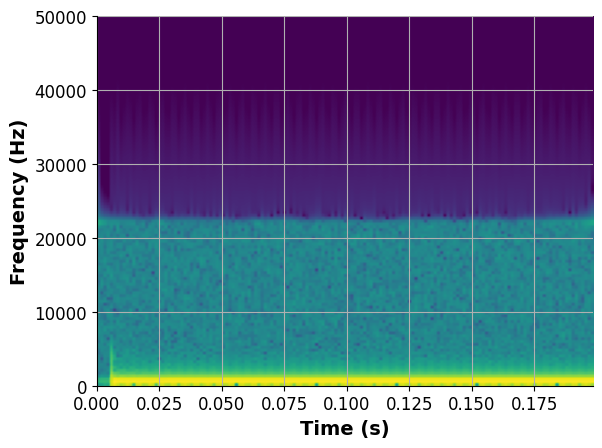

In [23]:
anf.left.spectrogram()

(array([[5.12225143e-15, 7.59273615e-15, 1.08241994e-13, ...,
         3.78907650e-08, 1.41796696e-08, 8.27715065e-10],
        [1.48584088e-14, 1.09180653e-14, 3.32075289e-13, ...,
         1.76570002e-07, 1.84429603e-07, 1.62127317e-07],
        [1.20422869e-14, 1.80311141e-14, 2.01937881e-13, ...,
         1.05858709e-07, 1.01061918e-07, 8.53541505e-08],
        ...,
        [1.00000000e-20, 1.00000000e-20, 1.00000000e-20, ...,
         1.00000000e-20, 1.00000000e-20, 1.00000000e-20],
        [1.00000000e-20, 1.00000000e-20, 1.00000000e-20, ...,
         1.00000000e-20, 1.00000000e-20, 1.00000000e-20],
        [1.00000000e-20, 1.00000000e-20, 1.00000000e-20, ...,
         1.00000000e-20, 1.00000000e-20, 1.00000000e-20]]),
 array([ 0.      ,  0.390625,  0.78125 ,  1.171875,  1.5625  ,  1.953125,
         2.34375 ,  2.734375,  3.125   ,  3.515625,  3.90625 ,  4.296875,
         4.6875  ,  5.078125,  5.46875 ,  5.859375,  6.25    ,  6.640625,
         7.03125 ,  7.421875,  7.8125  ,  8

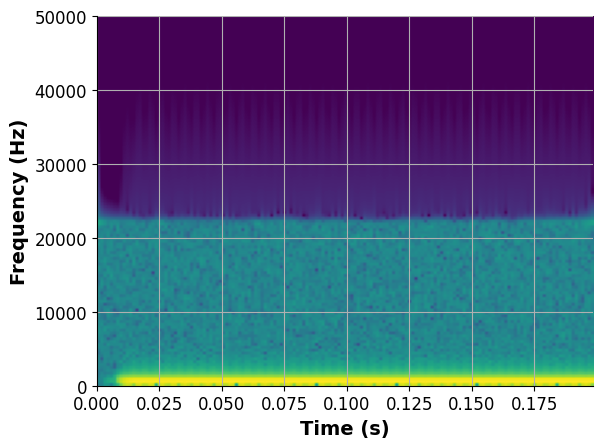

In [24]:
g_anf.left.spectrogram()

In [25]:
l_anf = anf.binaural_anf_spiketrain['L']
r_anf = anf.binaural_anf_spiketrain['R']

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'ANF Raster Plot'}, xlabel='Time (s)', ylabel='Neuron index'>)

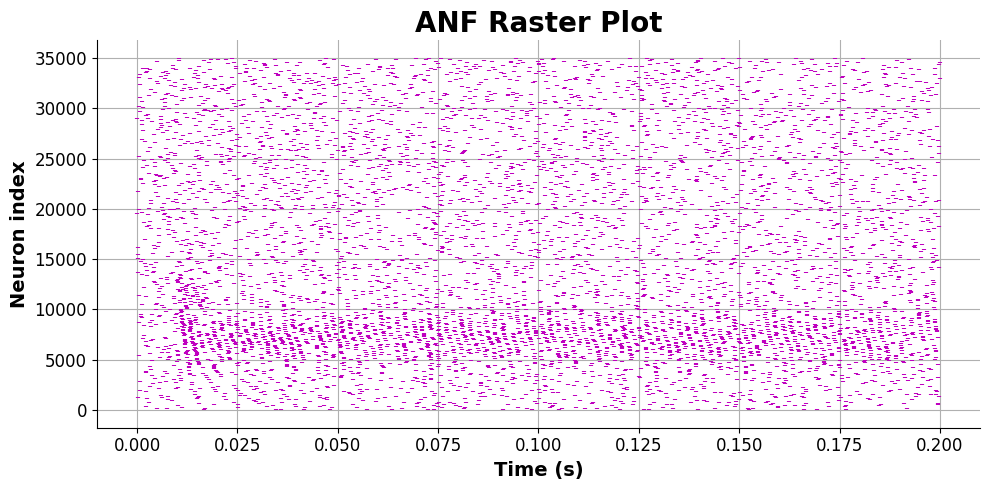

In [27]:
plot_anf_rasterplot(l_anf,color='m', linewidth=3)

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'ANF Raster Plot'}, xlabel='Time (s)', ylabel='Neuron index'>)

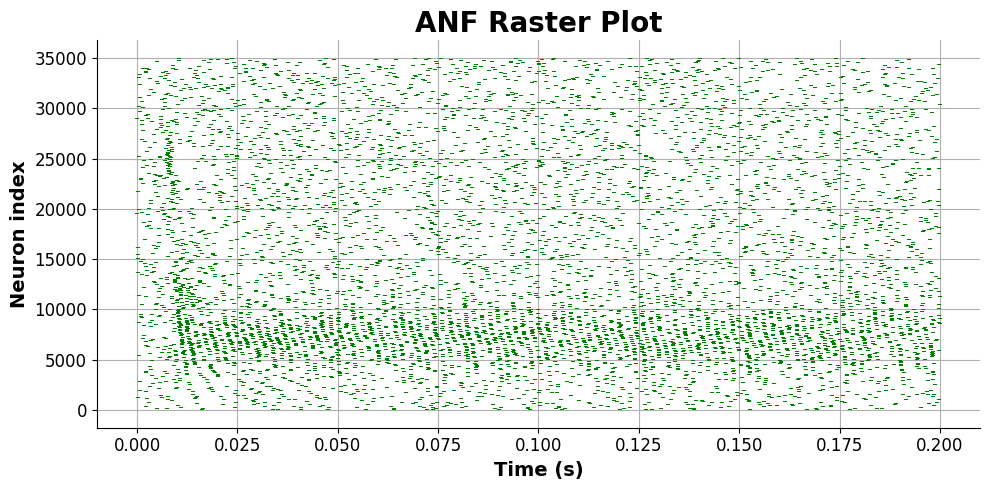

In [30]:
plot_anf_rasterplot(r_anf,color='g', linewidth=3)

In [28]:
g_l_anf = g_anf.binaural_anf_spiketrain['L']
g_r_anf = g_anf.binaural_anf_spiketrain['R']

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'ANF Raster Plot'}, xlabel='Time (s)', ylabel='Neuron index'>)

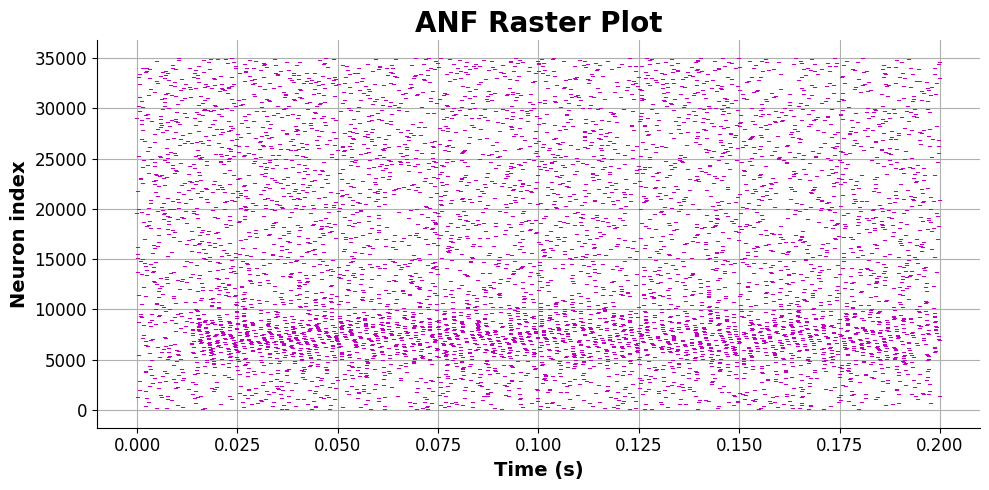

In [29]:
plot_anf_rasterplot(g_l_anf,color='m', linewidth=3)

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'ANF Raster Plot'}, xlabel='Time (s)', ylabel='Neuron index'>)

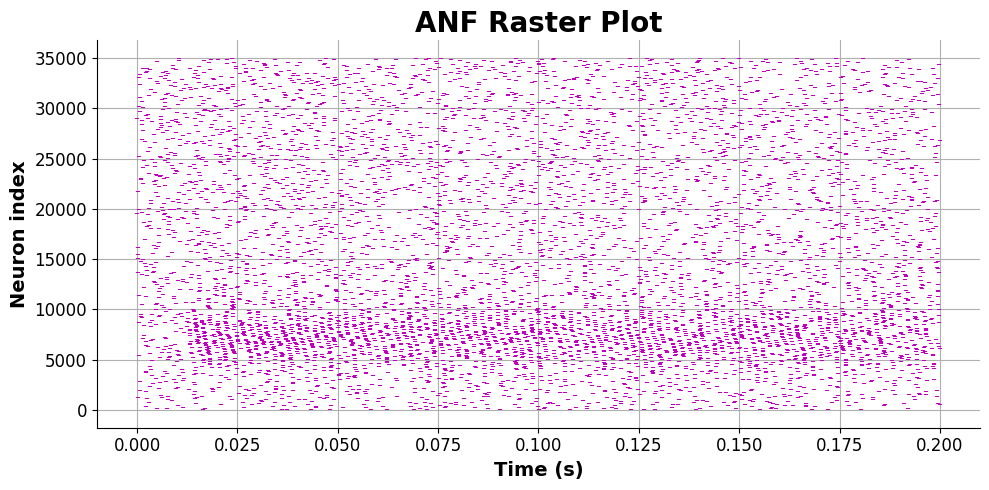

In [31]:
plot_anf_rasterplot(g_r_anf,color='m', linewidth=3)